In [1]:
import numpy as np
import pandas as pd
import keras_tuner as kt
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
import tensorflow as tf
import random

seed = 42

np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)

In [3]:
df = pd.read_csv('Data/data_preprocessing.csv', index_col='Date', parse_dates=True)
df.head()

,Precipitation,Temperature,Relative Humidity,Wind Speed
Date,,,,
1985-01-01,0.0,24.12,66.46,26.87
1985-01-02,0.0,24.27,66.08,26.60
1985-01-03,0.1,25.02,61.42,22.44
1985-01-04,0.2,25.26,60.54,22.89
1985-01-05,0.0,25.05,59.92,24.88


In [4]:
# Sắp xếp và kiểm tra dữ liệu
df = df.sort_index()

# kiểm tra liên tục thời gian
print(df.index.to_series().diff().value_counts().head())

Date
1 days    12204
Name: count, dtype: int64


In [5]:
# Chọn biến đầu vào & mục tiêu
features = ['Precipitation', 'Relative Humidity', 'Wind Speed']
target = 'Temperature'

X = df[features]
y = df[target]

In [6]:
# Chia tập dữ liệu: 70% train, 15% validation, 15% test
total_samples = len(X)
train_size = int(total_samples * 0.70)
val_size = int(total_samples * 0.15)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]

In [7]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8543, 3)
y_train shape: (8543,)
X_val shape: (1830, 3)
y_val shape: (1830,)
X_test shape: (1832, 3)
y_test shape: (1832,)


In [8]:
from sklearn.preprocessing import MinMaxScaler
# Chuẩn hóa dữ liệu
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled   = scaler_X.transform(X_val)
X_test_scaled  = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1))
y_val_scaled   = scaler_y.transform(y_val.values.reshape(-1,1))
y_test_scaled  = scaler_y.transform(y_test.values.reshape(-1,1))

In [9]:
# Hàm tạo chuỗi dữ liệu > Dự đoán ngày tiếp theo
def create_sequences(X, y, time_step):
    X_seq, y_seq = [], []
    
    for i in range(len(X) - time_step):
        X_seq.append(X[i:i + time_step])
        y_seq.append(y[i + time_step])
        
    return np.array(X_seq), np.array(y_seq)

In [10]:
# Xác định time_step = 30 
time_step = 30

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, time_step)
X_val_seq, y_val_seq     = create_sequences(X_val_scaled, y_val_scaled, time_step)
X_test_seq, y_test_seq   = create_sequences(X_test_scaled, y_test_scaled, time_step)

In [11]:
X_train_seq = X_train_seq.reshape((X_train_seq.shape[0], X_train_seq.shape[1], X_train_seq.shape[2]))
X_val_seq   = X_val_seq.reshape((X_val_seq.shape[0], X_val_seq.shape[1], X_val_seq.shape[2]))

In [12]:
print(X_train_seq.shape)
print(X_val_seq.shape)

(8513, 30, 3)
(1800, 30, 3)


In [13]:
# Khai báo thư viện
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np

In [14]:
import tensorflow as tf
from tensorflow.keras import layers

class LTCCell(layers.Layer):

    def __init__(self, units, **kwargs):
        super(LTCCell, self).__init__(**kwargs)
        self.units = units

    @property
    def state_size(self):
        return self.units

    @property
    def output_size(self):
        return self.units

    def build(self, input_shape):

        input_dim = input_shape[-1]

        self.W = self.add_weight(
            shape=(input_dim, self.units),
            initializer="glorot_uniform",
            name="W"
        )

        self.U = self.add_weight(
            shape=(self.units, self.units),
            initializer="orthogonal",
            name="U"
        )

        self.b = self.add_weight(
            shape=(self.units,),
            initializer="zeros",
            name="b"
        )

        self.tau = self.add_weight(
            shape=(self.units,),
            initializer="ones",
            name="tau"
        )

        self.gain = self.add_weight(
            shape=(self.units,),
            initializer="ones",
            name="gain"
        )

        super().build(input_shape)

    def call(self, inputs, states):

        prev_output = states[0]

        h = tf.matmul(inputs, self.W) + tf.matmul(prev_output, self.U) + self.b

        tau_clipped = tf.clip_by_value(self.tau, 0.1, 10.0)

        alpha = 1.0 / tau_clipped

        activation = tf.tanh(self.gain * h)

        output = (1 - alpha) * prev_output + alpha * activation

        return output, [output]

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, RNN, Dense
from tensorflow import keras

def build_lnn(hp):

    model = Sequential([

        Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])),

        RNN(
            LTCCell(
                units=hp.Int("ltc_units", 16, 64, step=16)
            )
        ),

        Dense(
            hp.Int("dense_units", 16, 64, step=16),
            activation="relu"
        ),

        Dense(1)

    ])

    model.compile(
        optimizer=keras.optimizers.Adam(
            hp.Float("learning_rate", 1e-4, 1e-2, sampling="log")
        ),
        loss="mse",
        metrics=["mae"]
    )

    return model

In [16]:
# import keras_tuner as kt

# tuner_lnn = kt.RandomSearch(
#     build_lnn,
#     objective="val_loss",
#     max_trials=20,
#     executions_per_trial=1,
#     seed=42,
#     overwrite=True,
#     directory="hyperparameter_tuning",
#     project_name="lnn_search"
# )
import keras_tuner as kt

tuner_lnn = kt.GridSearch(
    build_lnn,
    objective="val_loss",
    executions_per_trial=1,
    seed=42,
    overwrite=True,
    directory="hyperparameter_tuning",
    project_name="lnn_grid_search"
)

In [17]:
# tuner_lnn.search(
#     X_train_seq,
#     y_train_seq,
#     epochs=50,
#     validation_data=(X_val_seq, y_val_seq),
#     batch_size=32
# )
tuner_lnn.search(
    X_train_seq,
    y_train_seq,
    epochs=20,
    validation_data=(X_val_seq, y_val_seq),
    batch_size=32,
    shuffle=False
)

Trial 176 Complete [00h 00m 50s]
val_loss: 0.008198169060051441

Best val_loss So Far: 0.006870097480714321
Total elapsed time: 02h 28m 20s


In [18]:
best_model = tuner_lnn.get_best_models(num_models=1)[0]

C:\Users\user\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 20 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [19]:
best_hp = tuner_lnn.get_best_hyperparameters(1)[0]
print(best_hp.values)

{'ltc_units': 16, 'dense_units': 64, 'learning_rate': 0.00019952623149688798}


In [20]:
best_model_lnn= tuner_lnn.hypermodel.build(best_hp)

In [21]:
best_model_lnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rnn_1 (RNN)                          │ (None, 16)                  │             352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           1,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,505 (5.88 KB)

 Trainable params: 1,505 (5.88 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [27]:
history =best_model_lnn.fit(
    X_train_seq, y_train_seq,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_seq, y_val_seq),
    shuffle=False,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0086 - mae: 0.0721 - val_loss: 0.0073 - val_mae: 0.0655
Epoch 2/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0086 - mae: 0.0721 - val_loss: 0.0073 - val_mae: 0.0655
Epoch 3/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0086 - mae: 0.0720 - val_loss: 0.0073 - val_mae: 0.0655
Epoch 4/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0086 - mae: 0.0720 - val_loss: 0.0073 - val_mae: 0.0654
Epoch 5/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0086 - mae: 0.0720 - val_loss: 0.0073 - val_mae: 0.0654
Epoch 6/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0086 - mae: 0.0719 - val_loss: 0.0073 - val_mae: 0.0654
Epoch 7/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0085 - mae: 0.0719 - val_loss: 0.0073 - val_mae: 0.0654
Epoch 8/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0085 - mae: 0.0718 - val_loss: 0.0073 - val_mae: 0.0654
Epoch 9/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - lo

In [28]:
# Dự đoán trên tập kiểm tra
y_pred_scaled = best_model_lnn.predict(X_test_seq)

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step  


In [31]:
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_original = scaler_y.inverse_transform(y_test_seq)

In [32]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(y_test_original, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_original, y_pred)
r2 = r2_score(y_test_original, y_pred)

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)

MSE : 1.233160798732177
RMSE: 1.1104777344603434
MAE : 0.8468725984342618
R2  : 0.538062685519682


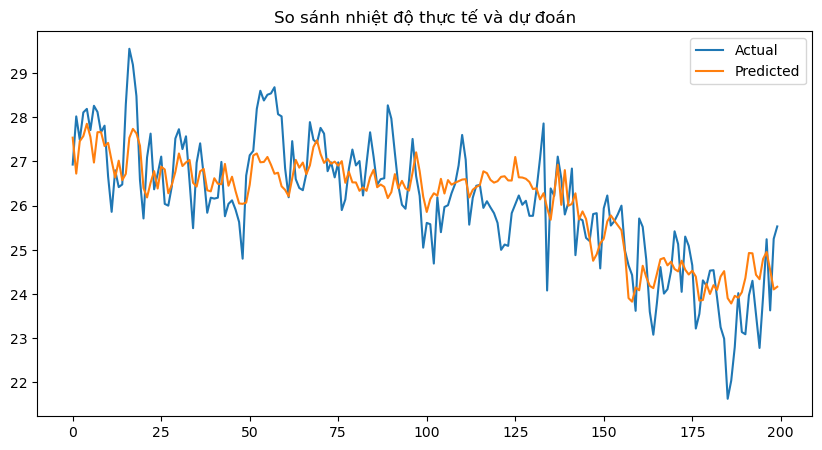

In [34]:
import matplotlib.pyplot as plt
# Vẽ biểu đồ so sánh Thực tế vs Dự đoán
plt.figure(figsize=(10,5))
plt.plot(y_test_original[:200], label="Actual")
plt.plot(y_pred[:200], label="Predicted")
plt.legend()
plt.title("So sánh nhiệt độ thực tế và dự đoán")
plt.show()

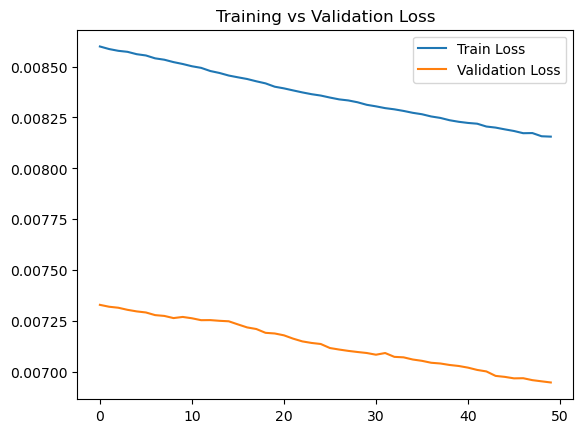

In [35]:
# Vẽ biểu đồ Loss trong quá trình train
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

In [36]:
print("===== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH =====")
print(f"Sai số bình phương trung bình (MSE): {mse:.4f}")
print(f"Căn bậc hai sai số (RMSE): {rmse:.4f} °C")
print(f"Sai số tuyệt đối trung bình (MAE): {mae:.4f} °C")
print(f"Hệ số xác định (R²): {r2:.4f}")

===== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH =====
Sai số bình phương trung bình (MSE): 1.2332
Căn bậc hai sai số (RMSE): 1.1105 °C
Sai số tuyệt đối trung bình (MAE): 0.8469 °C
Hệ số xác định (R²): 0.5381


In [37]:
mape = np.mean(np.abs((y_test_original - y_pred) / y_test_original)) * 100
print(f"Sai số phần trăm trung bình (MAPE): {mape:.2f}%")

Sai số phần trăm trung bình (MAPE): 3.21%


In [38]:
accuracy = 100 - mape
print(f"Độ chính xác (Accuracy): {accuracy:.2f}%")

Độ chính xác (Accuracy): 96.79%


In [39]:
best_model_lnn.save("best_model_lnn.keras")